In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint
plt.switch_backend('module://matplotlib_inline.backend_inline')

## Reweighting the samples
In this notebook, we explain how we reweight the samples to resemble the posterior that has narrower (wider) width because of the rescaling factor on the inverse covariance.

Use case: Consider that we are missing the Dodelson-Schneider correction factor $f$ in the analysis by mistake, and we want to reproduce the proper result with the correction using the uncorrected chain.

Method: Assuming the Gaussian likelihood, the likelihoods with/without correction are
$$
\begin{align}
\ln L &= -\frac{1}{2}\Delta C^{-1} \Delta + {\rm const} \\
\ln L_f &= -f\frac{1}{2}\Delta C^{-1} \Delta + {\rm const}'
\end{align}
$$
where the two constants are different but does not matter for the posterior shape.

Note that we can reproduce the corrected likelihood from the uncorrected likelihood up to a constant shift where the latter is what we already have
$$
\ln L_f = (f-1)\ln L + {\rm const}''
$$
Then we should be able to reproduce the corrected posterior by reweighting the sample in the chain by the factor of
$$
w\rightarrow w \times \exp[(f-1)\ln L]
$$

Technical note: we perform the rescaling to the samples that have sufficiently large relative weights. If the weights in the chain is too small, it usually indicates the samples are at the posterior tail and super small likelihood, for which up weighting tends to fail.

In [52]:
# Example chain
fname_example = '../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-all.txt'
mock1= utils.read_cosmosis_mcmc_des_chain(fname_example,
                                          to_mcsamples=True, 
                                          blind=False)

Removed no burn in


In [67]:
# Rescale the example chain by a factor of missing correction factor
# Here, we pretend as we missed the 0.8 correction factor in the inverse covariance
mock2= utils.read_cosmosis_mcmc_des_chain(fname_example,
                                          to_mcsamples=True, 
                                          blind=False, f_icov=0.8)

Removed no burn in


<Figure size 600x600 with 0 Axes>

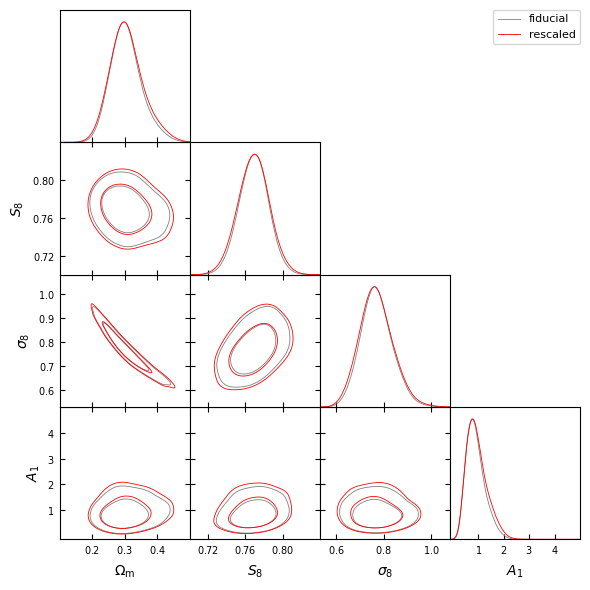

In [68]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([mock1, mock2], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['fiducial',  'rescaled'], legend_loc='upper right', 
    contour_colors=['gray', 'red'])
plt.show()

In [69]:
utils.FoM_from_samples_names(mock2, ['s8'])/utils.FoM_from_samples_names(mock1, ['s8'])

0.9313073749869407

In [70]:
utils.FoM_from_samples_names(mock2, ['om'])/utils.FoM_from_samples_names(mock1, ['om'])

0.9314427954455841

Okay. It seems the rescaling is working well as intended.